In [21]:
import sys
print(sys.executable)

c:\Users\balud\character-recognition-nn\venv\Scripts\python.exe


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont


numpy: 2.5.3
pillow: 12.3.0
matplotlib: 3.11.1


In [1]:
import matplotlib.font_manager as fm

font_paths = []
for f in fm.fontManager.ttflist:
    if f.fname.endswith(('.ttf', '.otf')):
        font_paths.append(f.fname)
print(f"Total font files found: {len(font_paths)}")

names = set()
for path in font_paths:
    try:
        names.add(fm.FontProperties(fname=path).get_name())
    except Exception:
        pass
print(f"Unique font families: {len(names)}")
print(sorted(names))

Total font files found: 191
Unique font families: 79
['Arial', 'Bahnschrift', 'Calibri', 'Cambria', 'Camera Obscura', 'Candara', 'Comic Sans MS', 'Consolas', 'Constantia', 'Corbel', 'Courier New', 'DejaVu Sans', 'DejaVu Sans Display', 'DejaVu Sans Mono', 'DejaVu Serif', 'DejaVu Serif Display', 'Ebrima', 'Franklin Gothic Medium', 'Gabriola', 'Gadugi', 'Georgia', 'Headliner No. 45', 'Impact', 'Ink Free', 'Javanese Text', 'Last Resort High-Efficiency', 'Leelawadee UI', 'Long Cool Grandma', 'Lucida Console', 'Lucida Sans Unicode', 'MV Boli', 'Malgun Gothic', 'Microsoft Himalaya', 'Microsoft New Tai Lue', 'Microsoft PhagsPa', 'Microsoft Sans Serif', 'Microsoft Tai Le', 'Microsoft Yi Baiti', 'Mongolian Baiti', 'Myanmar Text', 'Palatino Linotype', 'Roman SD', 'STIXGeneral', 'STIXNonUnicode', 'STIXSizeFiveSym', 'STIXSizeFourSym', 'STIXSizeOneSym', 'STIXSizeThreeSym', 'STIXSizeTwoSym', 'Sans Serif Collection', 'Segoe Fluent Icons', 'Segoe MDL2 Assets', 'Segoe Print', 'Segoe Script', 'Segoe UI',

In [24]:
EXCLUDE_FONTS = {
    'Wingdings', 'Webdings', 'Segoe Fluent Icons', 'Segoe MDL2 Assets',
    'Segoe UI Symbol', 'Segoe UI Emoji', 'Symbol',
    'Ebrima', 'Javanese Text', 'Leelawadee UI', 'Malgun Gothic',
    'Microsoft Himalaya', 'Microsoft New Tai Lue', 'Microsoft PhagsPa',
    'Microsoft Tai Le', 'Microsoft Yi Baiti', 'Mongolian Baiti',
    'Myanmar Text', 'SimSun-ExtB', 'SimSun-ExtG', 'Sylfaen', 'Gadugi',
    'STIXGeneral', 'STIXNonUnicode', 'STIXSizeFiveSym', 'STIXSizeFourSym',
    'STIXSizeOneSym', 'STIXSizeThreeSym', 'STIXSizeTwoSym',
    'cmb10', 'cmex10', 'cmmi10', 'cmr10', 'cmss10', 'cmsy10', 'cmti10', 'cmtt10',
    'Gabriola', 'Segoe Script', 'Segoe Print', 'Camera Obscura',
    'Headliner No. 45', 'Long Cool Grandma', 'Roman SD', 'Typo-Longest Thin Demo',
}

font_paths_named = []
for path in font_paths:
    try:
        name = fm.FontProperties(fname=path).get_name()
        if name not in EXCLUDE_FONTS:
            font_paths_named.append((name, path))
    except Exception:
        continue

# De-duplicate by family name, keep first occurrence
seen = set()
fonts = []
for name, path in font_paths_named:
    if name not in seen:
        seen.add(name)
        fonts.append(path)

print(f"Final usable fonts: {len(fonts)}")

Final usable fonts: 34


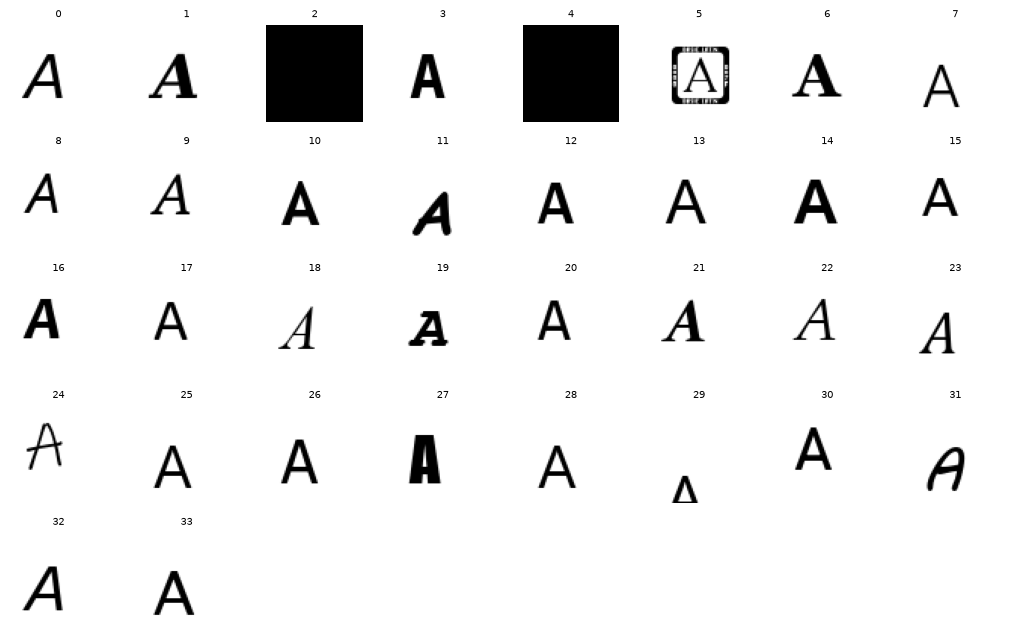

In [27]:
cols = 8
rows = (len(fonts) // cols) + 1
fig, axes = plt.subplots(rows, cols, figsize=(cols*1.3, rows*1.3))
axes = axes.flatten()

for i, font_path in enumerate(fonts):
    img = Image.new('L', (64, 64), color=255)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype(font_path, 40)
        draw.text((10, 10), 'A', fill=0, font=font)
    except Exception:
        pass
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(str(i), fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [29]:
bad_indices = [2, 4, 5, 29]
fonts = [f for i, f in enumerate(fonts) if i not in bad_indices]
print(f"Fonts remaining after visual cleanup: {len(fonts)}")

Fonts remaining after visual cleanup: 26


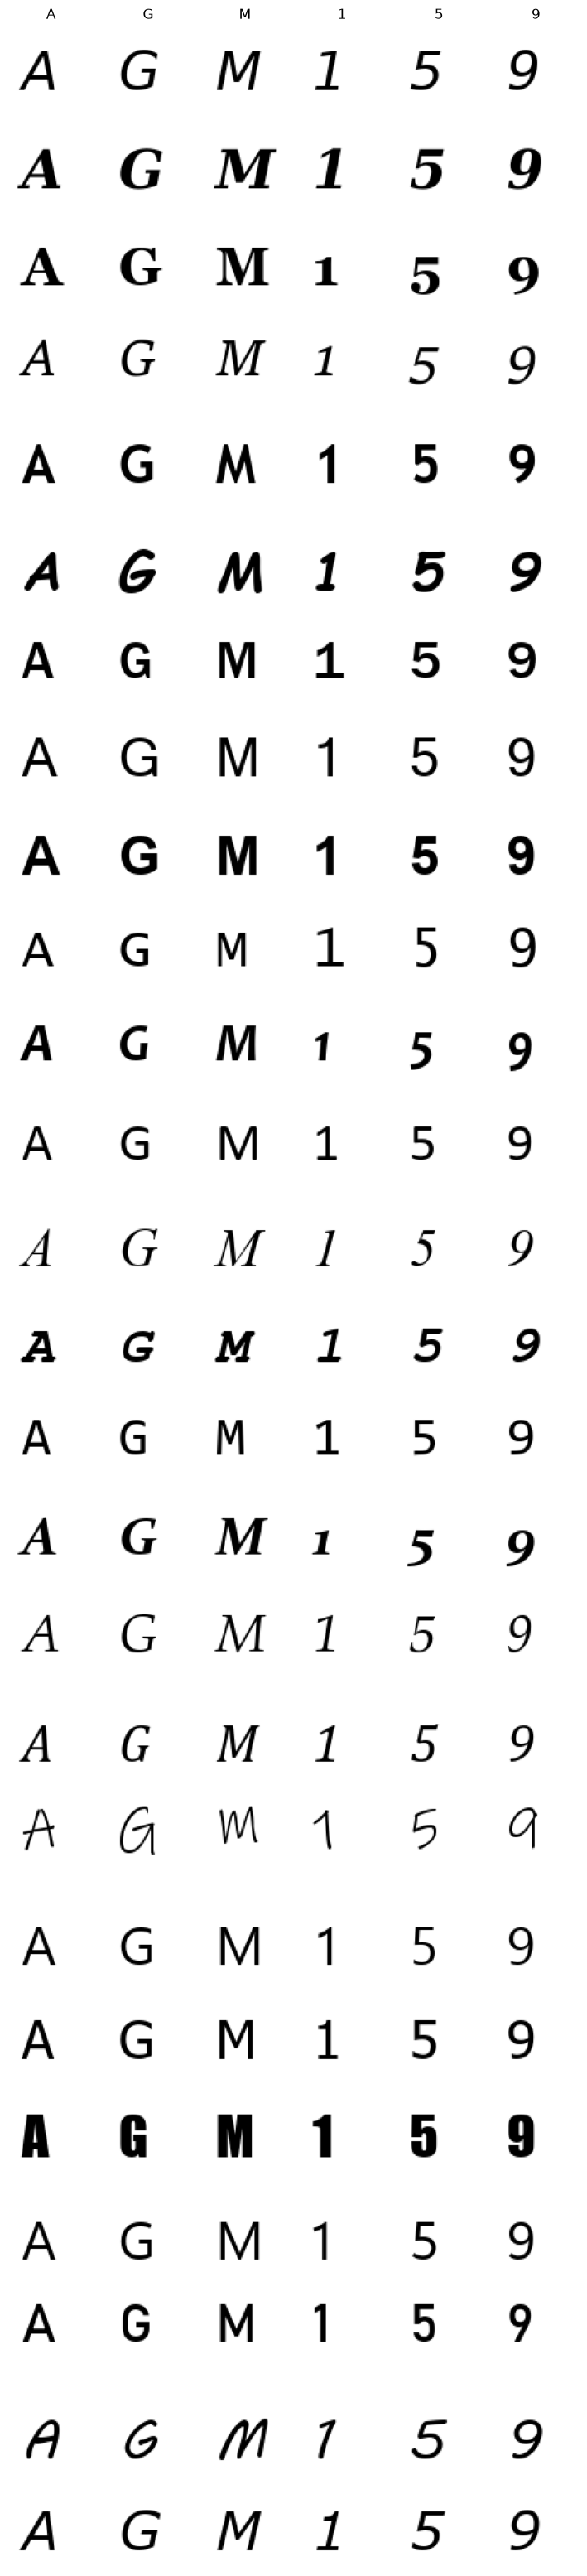

In [31]:
test_chars = ['A', 'G', 'M', '1', '5', '9']
fig, axes = plt.subplots(len(fonts), len(test_chars), figsize=(len(test_chars)*1.2, len(fonts)*1.2))

for i, font_path in enumerate(fonts):
    for j, ch in enumerate(test_chars):
        img = Image.new('L', (64, 64), color=255)
        draw = ImageDraw.Draw(img)
        try:
            font = ImageFont.truetype(font_path, 40)
            draw.text((10, 10), ch, fill=0, font=font)
        except Exception:
            pass
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(ch)

plt.tight_layout()
plt.show()

In [34]:
def render_character(char, font_path, image_size=64, font_size=48):
    """
    Renders a single character centered on a blank white square image.

    Parameters
    ----------
    char : str
        The single character to render (e.g. 'A', '7').
    font_path : str
        Full file path to a .ttf/.otf font file.
    image_size : int
        Width and height of the output square image, in pixels.
    font_size : int
        Font size used when drawing the character.

    Returns
    -------
    PIL.Image
        A grayscale ('L' mode) image with the character centered.
    """
    img = Image.new('L', (image_size, image_size), color=255)
    draw = ImageDraw.Draw(img)
    font = ImageFont.truetype(font_path, font_size)

    bbox = draw.textbbox((0, 0), char, font=font)
    text_w, text_h = bbox[2] - bbox[0], bbox[3] - bbox[1]
    pos = ((image_size - text_w) // 2 - bbox[0], (image_size - text_h) // 2 - bbox[1])

    draw.text(pos, char, fill=0, font=font)
    return img

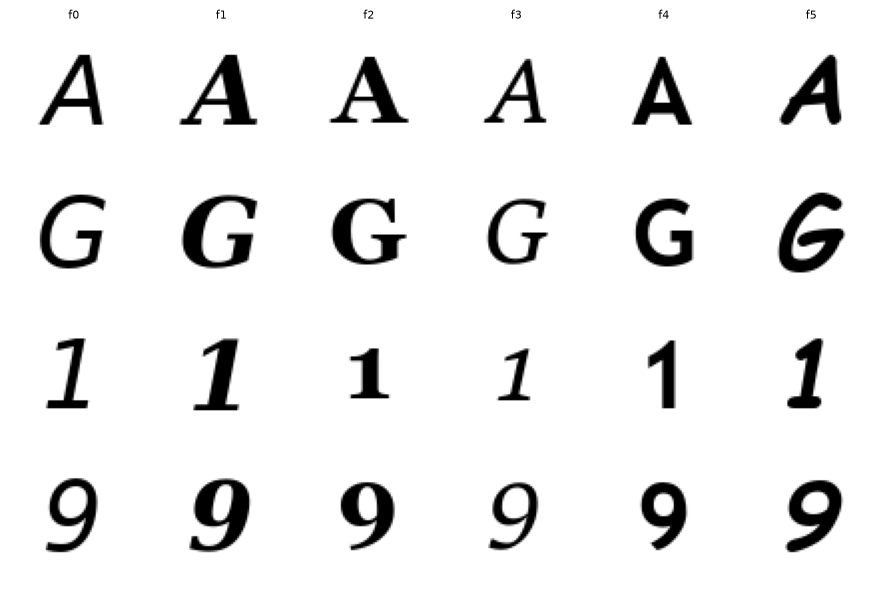

In [36]:
test_chars = ['A', 'G', '1', '9']
fig, axes = plt.subplots(len(test_chars), 6, figsize=(9, 6))

sample_fonts = fonts[:6]  # first 6 fonts from your cleaned list, as a spot check
for i, ch in enumerate(test_chars):
    for j, font_path in enumerate(sample_fonts):
        img = render_character(ch, font_path)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(f"f{j}", fontsize=8)

plt.tight_layout()
plt.show()

In [38]:
def augment_image(img, rng):
    """
    Applies random rotation, translation, and noise to simulate natural
    variation in character appearance.

    Parameters
    ----------
    img : PIL.Image
        The base rendered character (grayscale).
    rng : np.random.Generator
        Seeded random generator, for reproducibility.

    Returns
    -------
    PIL.Image
        The augmented image, same size as input.
    """
    angle = rng.uniform(-12, 12)
    img = img.rotate(angle, fillcolor=255, resample=Image.BICUBIC)

    dx, dy = rng.integers(-4, 5), rng.integers(-4, 5)
    img = img.transform(img.size, Image.AFFINE, (1, 0, dx, 0, 1, dy), fillcolor=255)

    arr = np.array(img).astype(np.float32)
    noise = rng.normal(0, 8, arr.shape)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)

    return Image.fromarray(arr)

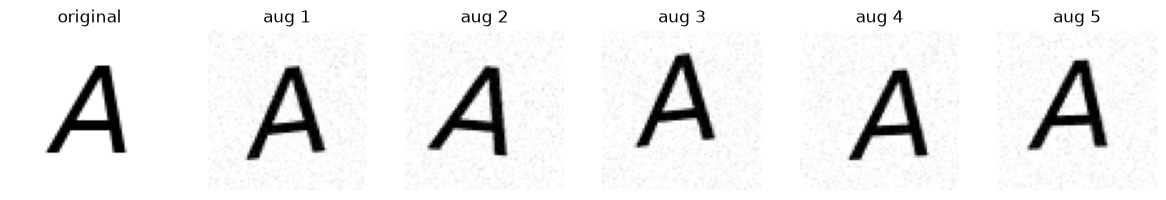

In [40]:
rng = np.random.default_rng(42)
base = render_character('A', fonts[0])

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
axes[0].imshow(base, cmap='gray')
axes[0].set_title("original")
axes[0].axis('off')

for i in range(1, 6):
    aug = augment_image(base, rng)
    axes[i].imshow(aug, cmap='gray')
    axes[i].set_title(f"aug {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [43]:
def preprocess_image(img, target_size=28):
    """
    Resizes an image to the fixed target size and normalizes pixel values
    to the [0, 1] range.

    Parameters
    ----------
    img : PIL.Image
        Input grayscale image (any size).
    target_size : int
        Output width/height in pixels (square).

    Returns
    -------
    np.ndarray
        Flattened 1D array of length target_size*target_size, values in [0,1].
    """
    img = img.resize((target_size, target_size), Image.LANCZOS)
    arr = np.array(img).astype(np.float32) / 255.0
    return arr.flatten()

Shape: (784,)
Min/Max: 0.0 1.0


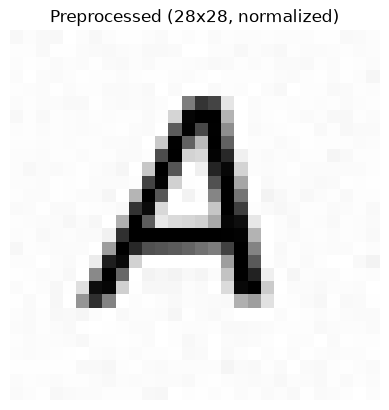

In [45]:
vec = preprocess_image(aug, target_size=28)

print("Shape:", vec.shape)          # expect (784,)
print("Min/Max:", vec.min(), vec.max())  # expect within [0, 1]

plt.imshow(vec.reshape(28, 28), cmap='gray')
plt.title("Preprocessed (28x28, normalized)")
plt.axis('off')
plt.show()

In [47]:
def build_dataset(fonts, samples_per_class=400, seed=42):
    """
    Generates the full labeled character dataset across all 35 classes
    (uppercase A-Z and digits 1-9), by rendering each character in a
    randomly chosen font and applying random augmentation for every sample.

    Parameters
    ----------
    fonts : list of str
        File paths to the cleaned, verified font files.
    samples_per_class : int
        Number of augmented samples to generate per class.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    X : np.ndarray, shape (n_samples, 784)
        Flattened, normalized pixel vectors.
    y : np.ndarray, shape (n_samples,)
        Integer class labels (0-25 = A-Z, 26-34 = 1-9).
    class_names : list of str
        Human-readable label for each class index.
    """
    rng = np.random.default_rng(seed)
    classes = [chr(c) for c in range(ord('A'), ord('Z')+1)] + [str(d) for d in range(1, 10)]

    X, y = [], []
    for class_idx, char in enumerate(classes):
        for _ in range(samples_per_class):
            font_path = fonts[rng.integers(0, len(fonts))]
            base_img = render_character(char, font_path, image_size=64, font_size=48)
            aug_img = augment_image(base_img, rng)
            vec = preprocess_image(aug_img, target_size=28)
            X.append(vec)
            y.append(class_idx)
        print(f"Generated class '{char}' ({class_idx+1}/35)")

    return np.array(X), np.array(y), classes

In [50]:
X, y, class_names = build_dataset(fonts, samples_per_class=400)
print(X.shape, y.shape)

Generated class 'A' (1/35)
Generated class 'B' (2/35)
Generated class 'C' (3/35)
Generated class 'D' (4/35)
Generated class 'E' (5/35)
Generated class 'F' (6/35)
Generated class 'G' (7/35)
Generated class 'H' (8/35)
Generated class 'I' (9/35)
Generated class 'J' (10/35)
Generated class 'K' (11/35)
Generated class 'L' (12/35)
Generated class 'M' (13/35)
Generated class 'N' (14/35)
Generated class 'O' (15/35)
Generated class 'P' (16/35)
Generated class 'Q' (17/35)
Generated class 'R' (18/35)
Generated class 'S' (19/35)
Generated class 'T' (20/35)
Generated class 'U' (21/35)
Generated class 'V' (22/35)
Generated class 'W' (23/35)
Generated class 'X' (24/35)
Generated class 'Y' (25/35)
Generated class 'Z' (26/35)
Generated class '1' (27/35)
Generated class '2' (28/35)
Generated class '3' (29/35)
Generated class '4' (30/35)
Generated class '5' (31/35)
Generated class '6' (32/35)
Generated class '7' (33/35)
Generated class '8' (34/35)
Generated class '9' (35/35)
(14000, 784) (14000,)


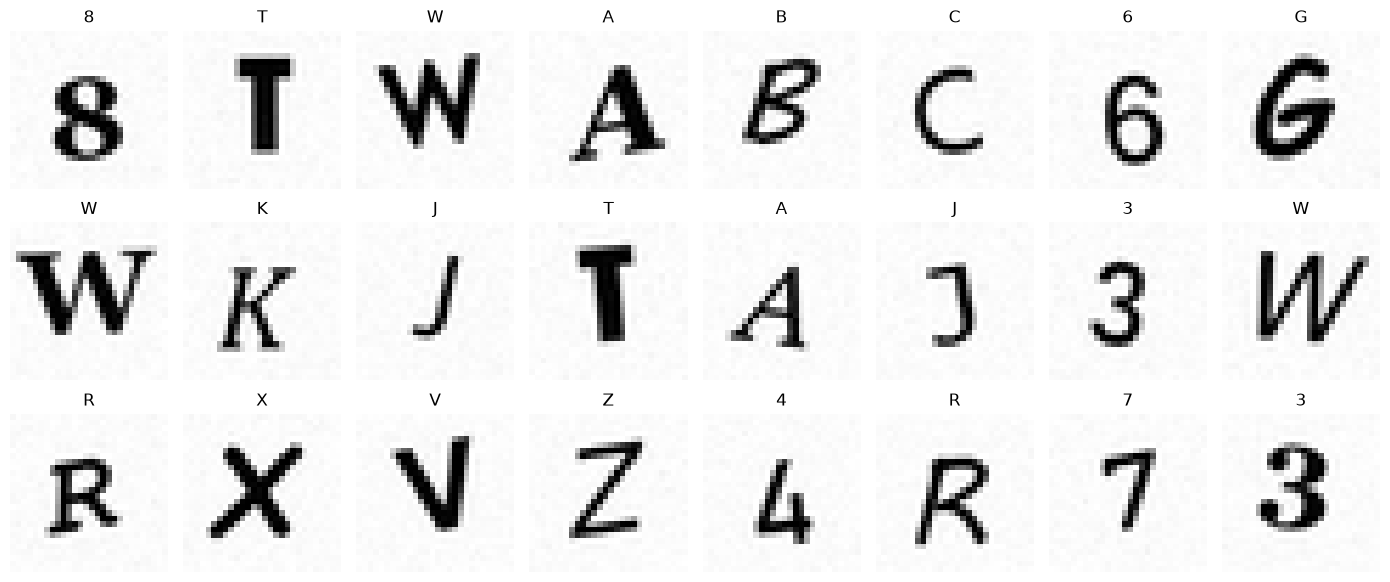

In [52]:
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
rng_check = np.random.default_rng(0)
idxs = rng_check.choice(len(X), 24, replace=False)

for ax, i in zip(axes.flatten(), idxs):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(class_names[y[i]])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [54]:
def stratified_split(X, y, train_frac=0.7, val_frac=0.15, seed=42):
    """
    Splits data into train/validation/test sets while preserving class
    proportions (stratified) -- every class appears in all three sets
    in roughly the same ratio.

    Parameters
    ----------
    X : np.ndarray
        Feature matrix, shape (n_samples, n_features).
    y : np.ndarray
        Integer class labels, shape (n_samples,).
    train_frac : float
        Fraction of each class's samples assigned to the training set.
    val_frac : float
        Fraction assigned to validation (remainder goes to test).
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    (X_train, y_train), (X_val, y_val), (X_test, y_test)
    """
    rng = np.random.default_rng(seed)
    n_classes = y.max() + 1
    train_idx, val_idx, test_idx = [], [], []

    for c in range(n_classes):
        idx = np.where(y == c)[0]
        rng.shuffle(idx)
        n = len(idx)
        n_train = int(n * train_frac)
        n_val = int(n * val_frac)
        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train:n_train+n_val])
        test_idx.extend(idx[n_train+n_val:])

    train_idx, val_idx, test_idx = map(np.array, (train_idx, val_idx, test_idx))
    rng.shuffle(train_idx); rng.shuffle(val_idx); rng.shuffle(test_idx)

    return (X[train_idx], y[train_idx]), (X[val_idx], y[val_idx]), (X[test_idx], y[test_idx])

(X_train, y_train), (X_val, y_val), (X_test, y_test) = stratified_split(X, y)
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (9800, 784) Val: (2100, 784) Test: (2100, 784)


In [56]:
import os
os.makedirs('../data', exist_ok=True)

np.savez('../data/character_dataset.npz',
         X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val,
         X_test=X_test, y_test=y_test,
         class_names=class_names)

print("Saved to ../data/character_dataset.npz")

Saved to ../data/character_dataset.npz


Train: (9800, 784) (9800,)
Val:   (2100, 784) (2100,)
Test:  (2100, 784) (2100,)
Train class counts: [280 280 280 280 280 280 280 280 280 280 280 280 280 280 280 280 280 280
 280 280 280 280 280 280 280 280 280 280 280 280 280 280 280 280 280]
Val class counts:   [60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60
 60 60 60 60 60 60 60 60 60 60 60]
Test class counts:  [60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60 60
 60 60 60 60 60 60 60 60 60 60 60]
Reload matches original.


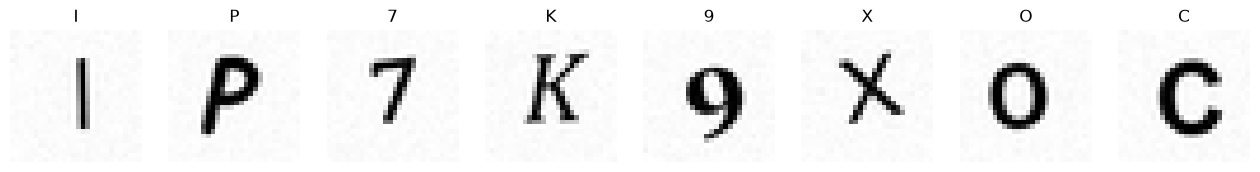

In [57]:
# 1. Confirm split shapes and per-class balance
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

print("Train class counts:", np.bincount(y_train))
print("Val class counts:  ", np.bincount(y_val))
print("Test class counts: ", np.bincount(y_test))

# 2. Reload from disk and confirm it matches what's in memory
data = np.load('../data/character_dataset.npz', allow_pickle=True)
X_train_loaded, y_train_loaded = data['X_train'], data['y_train']
class_names_loaded = data['class_names']

assert np.array_equal(X_train_loaded, X_train)
assert np.array_equal(y_train_loaded, y_train)
print("Reload matches original.")

# 3. Visual spot check
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
rng_check = np.random.default_rng(0)
idxs = rng_check.choice(len(X_train_loaded), size=8, replace=False)
for ax, idx in zip(axes, idxs):
    ax.imshow(X_train_loaded[idx].reshape(28, 28), cmap='gray')
    ax.set_title(class_names_loaded[y_train_loaded[idx]])
    ax.axis('off')
plt.show()